**PHYSICS-INFORMED NEURAL NETWORKS (PINNs) FOR BURGERS' EQUATION
Google Colab | TensorFlow 2.x**

Imports & Seeds

In [ ]:
import os
import time
import urllib.request

import numpy as np
import scipy.io
import scipy.optimize
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import tensorflow as tf

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow :", tf.__version__)
print("GPUs found :", tf.config.list_physical_devices("GPU"))

TensorFlow : 2.20.0
GPUs found : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Download Reference Data  (burgers_shock.mat)
*  The .mat file is a high-resolution finite-difference solution from the
*  original authors. It serves as ground truth for error analysis.
*   Source: https://github.com/maziarraissi/PINNs/blob/master/main/Data/

In [ ]:
DATA_FILE = "burgers_shock.mat"

if not os.path.exists(DATA_FILE):
    print("Downloading burgers_shock.mat from GitHub ...")
    URL = (
        "https://raw.githubusercontent.com/maziarraissi/PINNs/"
        "master/main/Data/burgers_shock.mat"
    )
    urllib.request.urlretrieve(URL, DATA_FILE)
    print("Download complete.")
else:
    print("Data file already present.")

Data file already present.


Load & Inspect Reference Data

In [ ]:
raw = scipy.io.loadmat(DATA_FILE)

t_star = raw["t"].flatten()       # shape (100,)  – time points in [0, 1]
x_star = raw["x"].flatten()       # shape (256,)  – space points in [-1, 1]
u_star = np.real(raw["usol"])     # shape (256, 100) – exact FD solution

print(f"t : {t_star.shape}  range [{t_star.min():.2f}, {t_star.max():.2f}]")
print(f"x : {x_star.shape}  range [{x_star.min():.2f}, {x_star.max():.2f}]")
print(f"u : {u_star.shape}")

# Full meshgrid – used for plotting and error computation
T_mesh, X_mesh = np.meshgrid(t_star, x_star)   # each (256, 100)

t : (100,)  range [0.00, 0.99]
x : (256,)  range [-1.00, 1.00]
u : (256, 100)


Generate Training Data

Two types of training points:
*   N_u – IC / BC points where u is KNOWN exactly
*    N_f – Collocation points where ONLY the PDE residual is enforced
         (u is unknown here; we just demand the equation = 0)
Latin Hypercube Sampling (LHS) distributes N_f points more uniformly
across the domain than pure random sampling.

In [ ]:
import sys
# Removed pyDOE installation and import as it was causing persistent ModuleNotFoundError.
# Using scipy.stats.qmc.LatinHypercube as a robust alternative for LHS.
from scipy.stats import qmc


NU  = 0.01 / np.pi    # kinematic viscosity  (~0.00318)
N_u = 100             # number of IC + BC training points
N_f = 10_000          # number of collocation points

# ── 5a. Collect ALL IC / BC points ──────────────────────────────────────────

# Initial condition  t = 0,  u(0, x) = -sin(pi*x)
t_ic = np.zeros((len(x_star), 1))
x_ic = x_star.reshape(-1, 1)
u_ic = -np.sin(np.pi * x_star).reshape(-1, 1)

# Left boundary   x = -1,  u = 0  for all t
t_lb = t_star.reshape(-1, 1)
x_lb = -np.ones((len(t_star), 1))
u_lb = np.zeros((len(t_star), 1))

# Right boundary  x = +1,  u = 0  for all t
t_rb = t_star.reshape(-1, 1)
x_rb = np.ones((len(t_star), 1))
u_rb = np.zeros((len(t_star), 1))

# Pool all IC/BC points, then randomly draw N_u of them
t_bc_all = np.vstack([t_ic, t_lb, t_rb])   # (256+100+100, 1)
x_bc_all = np.vstack([x_ic, x_lb, x_rb])
u_bc_all = np.vstack([u_ic, u_lb, u_rb])

idx = np.random.choice(len(t_bc_all), N_u, replace=False)
t_train_u = t_bc_all[idx]    # (N_u, 1)
x_train_u = x_bc_all[idx]    # (N_u, 1)
u_train_u = u_bc_all[idx]    # (N_u, 1)

# ── 5b. Collocation points via Latin Hypercube Sampling ─────────────────────
sampler = qmc.LatinHypercube(d=2)
lhs_pts   = sampler.random(n=N_f)           # (N_f, 2), values in [0, 1]
t_train_f = lhs_pts[:, 0:1]                   # t already in [0, 1]
x_train_f = -1.0 + 2.0 * lhs_pts[:, 1:2]     # x scaled to [-1, 1]

print(f"\nIC/BC points  (N_u) : {N_u}")
print(f"Collocation   (N_f) : {N_f}")
print(f"t_train_u shape     : {t_train_u.shape}")
print(f"t_train_f shape     : {t_train_f.shape}")


IC/BC points  (N_u) : 100
Collocation   (N_f) : 10000
t_train_u shape     : (100, 1)
t_train_f shape     : (10000, 1)


CELL 6 | Define the PINN Model

 Architecture (as in the original paper):

*   Input  : 2 neurons  (t, x)
*   Hidden : 8 layers x 20 neurons,  tanh activation

 **Output** : 1 neuron   (predicted u)
Loss = MSE_u  +  MSE_f

**MSE_u** : mean squared error on IC/BC points            (data loss)

**MSE_f** : mean squared PDE residual at collocation pts  (physics loss

In [ ]:
class BurgersPINN(tf.keras.Model):
    """PINN for the 1-D viscous Burgers equation."""

    def __init__(self, layer_sizes, nu):
        super().__init__()
        self.nu = tf.constant(nu, dtype=tf.float64)

        # Hidden layers with tanh activation
        self.dense_layers = [
            tf.keras.layers.Dense(
                n,
                activation="tanh",
                dtype=tf.float64,
                kernel_initializer="glorot_normal",
            )
            for n in layer_sizes[1:-1]
        ]
        # Output layer – no activation (pure regression)
        self.out = tf.keras.layers.Dense(
            layer_sizes[-1],
            activation=None,
            dtype=tf.float64,
            kernel_initializer="glorot_normal",
        )

    # ── Forward pass ─────────────────────────────────────────────────────────
    def call(self, t, x):
        z = tf.concat([t, x], axis=1)
        for layer in self.dense_layers:
            z = layer(z)
        return self.out(z)

    # ── Automatic differentiation ─────────────────────────────────────────────
    def derivatives(self, t, x):
        """
        Compute u, u_t, u_x, u_xx via nested GradientTapes.
        Nested tapes are needed to reach second-order derivatives.
        """
        with tf.GradientTape(persistent=True) as tape2:
            tape2.watch([t, x])
            with tf.GradientTape(persistent=True) as tape1:
                tape1.watch([t, x])
                u = self.call(t, x)
            u_t = tape1.gradient(u, t)    # du/dt
            u_x = tape1.gradient(u, x)    # du/dx
            del tape1
        u_xx = tape2.gradient(u_x, x)    # d2u/dx2
        del tape2
        return u, u_t, u_x, u_xx

    # ── PDE residual ──────────────────────────────────────────────────────────
    def residual(self, t_f, x_f):
        """f = u_t + u*u_x - nu*u_xx   (should be 0 everywhere)"""
        u, u_t, u_x, u_xx = self.derivatives(t_f, x_f)
        return u_t + u * u_x - self.nu * u_xx

    # ── Combined loss ─────────────────────────────────────────────────────────
    def total_loss(self, t_u, x_u, u_true, t_f, x_f):
        u_pred = self.call(t_u, x_u)
        mse_u  = tf.reduce_mean(tf.square(u_true - u_pred))
        mse_f  = tf.reduce_mean(tf.square(self.residual(t_f, x_f)))
        return mse_u + mse_f, mse_u, mse_f


Instantiate Model & Convert Data to Tensors

In [ ]:
LAYER_SIZES = [2, 20, 20, 20, 20, 20, 20, 20, 20, 1]   # 9-layer, 20 wide

model = BurgersPINN(LAYER_SIZES, NU)

# Convert numpy arrays to float64 tensors once
t_u = tf.constant(t_train_u, dtype=tf.float64)
x_u = tf.constant(x_train_u, dtype=tf.float64)
u_u = tf.constant(u_train_u, dtype=tf.float64)

# Collocation points as Variables so GradientTape can differentiate w.r.t. them
t_f = tf.Variable(t_train_f, dtype=tf.float64)
x_f = tf.Variable(x_train_f, dtype=tf.float64)

Phase 1 Training – Adam Optimiser

In [ ]:
ADAM_EPOCHS = 5_000
LOG_EVERY   = 500

adam         = tf.keras.optimizers.Adam(learning_rate=1e-3)
loss_history = {"total": [], "mse_u": [], "mse_f": []}

print("=" * 55)
print("Phase 1 — Adam optimisation")
print("=" * 55)

t_start = time.time()

for epoch in range(1, ADAM_EPOCHS + 1):
    with tf.GradientTape() as tape:
        loss, mse_u, mse_f = model.total_loss(t_u, x_u, u_u, t_f, x_f)
    grads = tape.gradient(loss, model.trainable_variables)
    adam.apply_gradients(zip(grads, model.trainable_variables))

    loss_history["total"].append(float(loss))
    loss_history["mse_u"].append(float(mse_u))
    loss_history["mse_f"].append(float(mse_f))

    if epoch % LOG_EVERY == 0 or epoch == 1:
        elapsed = time.time() - t_start
        print(
            f"Epoch {epoch:5d}/{ADAM_EPOCHS}"
            f"  |  Loss {float(loss):.4e}"
            f"  |  MSE_u {float(mse_u):.4e}"
            f"  |  MSE_f {float(mse_f):.4e}"
            f"  |  {elapsed:.1f}s"
        )

print(f"\nAdam done in {time.time() - t_start:.1f}s")


Phase 1 — Adam optimisation
Epoch     1/5000  |  Loss 2.5516e-01  |  MSE_u 2.5156e-01  |  MSE_f 3.5998e-03  |  5.4s
Epoch   500/5000  |  Loss 4.5185e-02  |  MSE_u 2.4527e-02  |  MSE_f 2.0658e-02  |  111.7s
Epoch  1000/5000  |  Loss 2.6842e-02  |  MSE_u 1.7866e-02  |  MSE_f 8.9757e-03  |  221.2s
Epoch  1500/5000  |  Loss 1.7727e-02  |  MSE_u 1.1400e-02  |  MSE_f 6.3276e-03  |  332.3s
Epoch  2000/5000  |  Loss 1.3173e-02  |  MSE_u 7.8730e-03  |  MSE_f 5.3004e-03  |  429.1s
Epoch  2500/5000  |  Loss 1.1507e-02  |  MSE_u 6.2637e-03  |  MSE_f 5.2437e-03  |  525.4s
Epoch  3000/5000  |  Loss 8.3467e-03  |  MSE_u 4.4126e-03  |  MSE_f 3.9341e-03  |  622.0s
Epoch  3500/5000  |  Loss 7.2862e-03  |  MSE_u 3.3036e-03  |  MSE_f 3.9827e-03  |  719.1s
Epoch  4000/5000  |  Loss 9.2493e-03  |  MSE_u 2.6685e-03  |  MSE_f 6.5808e-03  |  814.3s
Epoch  4500/5000  |  Loss 4.5931e-03  |  MSE_u 2.1301e-03  |  MSE_f 2.4629e-03  |  910.8s
Epoch  5000/5000  |  Loss 7.6386e-03  |  MSE_u 2.1113e-03  |  MSE_f 5.5272

Phase 2 Training – L-BFGS  (via scipy)

In [ ]:
lbfgs_loss_history = []

def get_weights():
    """All trainable weights as a single flat float64 numpy array."""
    return np.concatenate(
        [w.numpy().flatten() for w in model.trainable_variables]
    )

def set_weights(flat_w):
    """Write a flat numpy array back into the model's trainable variables."""
    idx = 0
    for var in model.trainable_variables:
        size = int(np.prod(var.shape))
        var.assign(
            tf.reshape(
                tf.constant(flat_w[idx : idx + size], dtype=tf.float64),
                var.shape,
            )
        )
        idx += size

def loss_and_grad(flat_w):
    """scipy callback: returns (scalar_loss, flat_gradient) as float64."""
    set_weights(flat_w)
    with tf.GradientTape() as tape:
        loss, _, _ = model.total_loss(t_u, x_u, u_u, t_f, x_f)
    grads = tape.gradient(loss, model.trainable_variables)
    flat_g = np.concatenate([g.numpy().flatten() for g in grads])
    lbfgs_loss_history.append(float(loss))
    return float(loss), flat_g.astype(np.float64)

print("\n" + "=" * 55)
print("Phase 2 — L-BFGS optimisation")
print("=" * 55)

t_lbfgs = time.time()

result = scipy.optimize.minimize(
    loss_and_grad,
    get_weights(),
    method="L-BFGS-B",
    jac=True,
    options={
        "maxiter": 50_000,
        "maxfun":  50_000,
        "ftol":    1e-12,
        "gtol":    1e-8,
    },
)

set_weights(result.x)   # restore best weights

print(f"L-BFGS done in {time.time() - t_lbfgs:.1f}s")
print(f"Success  : {result.success}")
print(f"Message  : {result.message}")
print(f"Final loss: {result.fun:.4e}")

loss_history["total"].extend(lbfgs_loss_history)


Phase 2 — L-BFGS optimisation
L-BFGS done in 5240.4s
Success  : True
Message  : CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Final loss: 7.7239e-07


Prediction & Error Analysis

In [ ]:
# Flatten the full space-time grid for batch prediction
T_flat = T_mesh.flatten()[:, None]
X_flat = X_mesh.flatten()[:, None]

t_pred_tf = tf.constant(T_flat, dtype=tf.float64)
x_pred_tf = tf.constant(X_flat, dtype=tf.float64)

u_pred = model(t_pred_tf, x_pred_tf).numpy().reshape(T_mesh.shape)  # (256, 100)

# Relative L2 error
l2_error = (
    np.linalg.norm(u_star - u_pred) / np.linalg.norm(u_star)
)
print(f"\nRelative L2 error : {l2_error:.4e}")


Relative L2 error : 5.5041e-04


Visualisation – 4-panel Figure

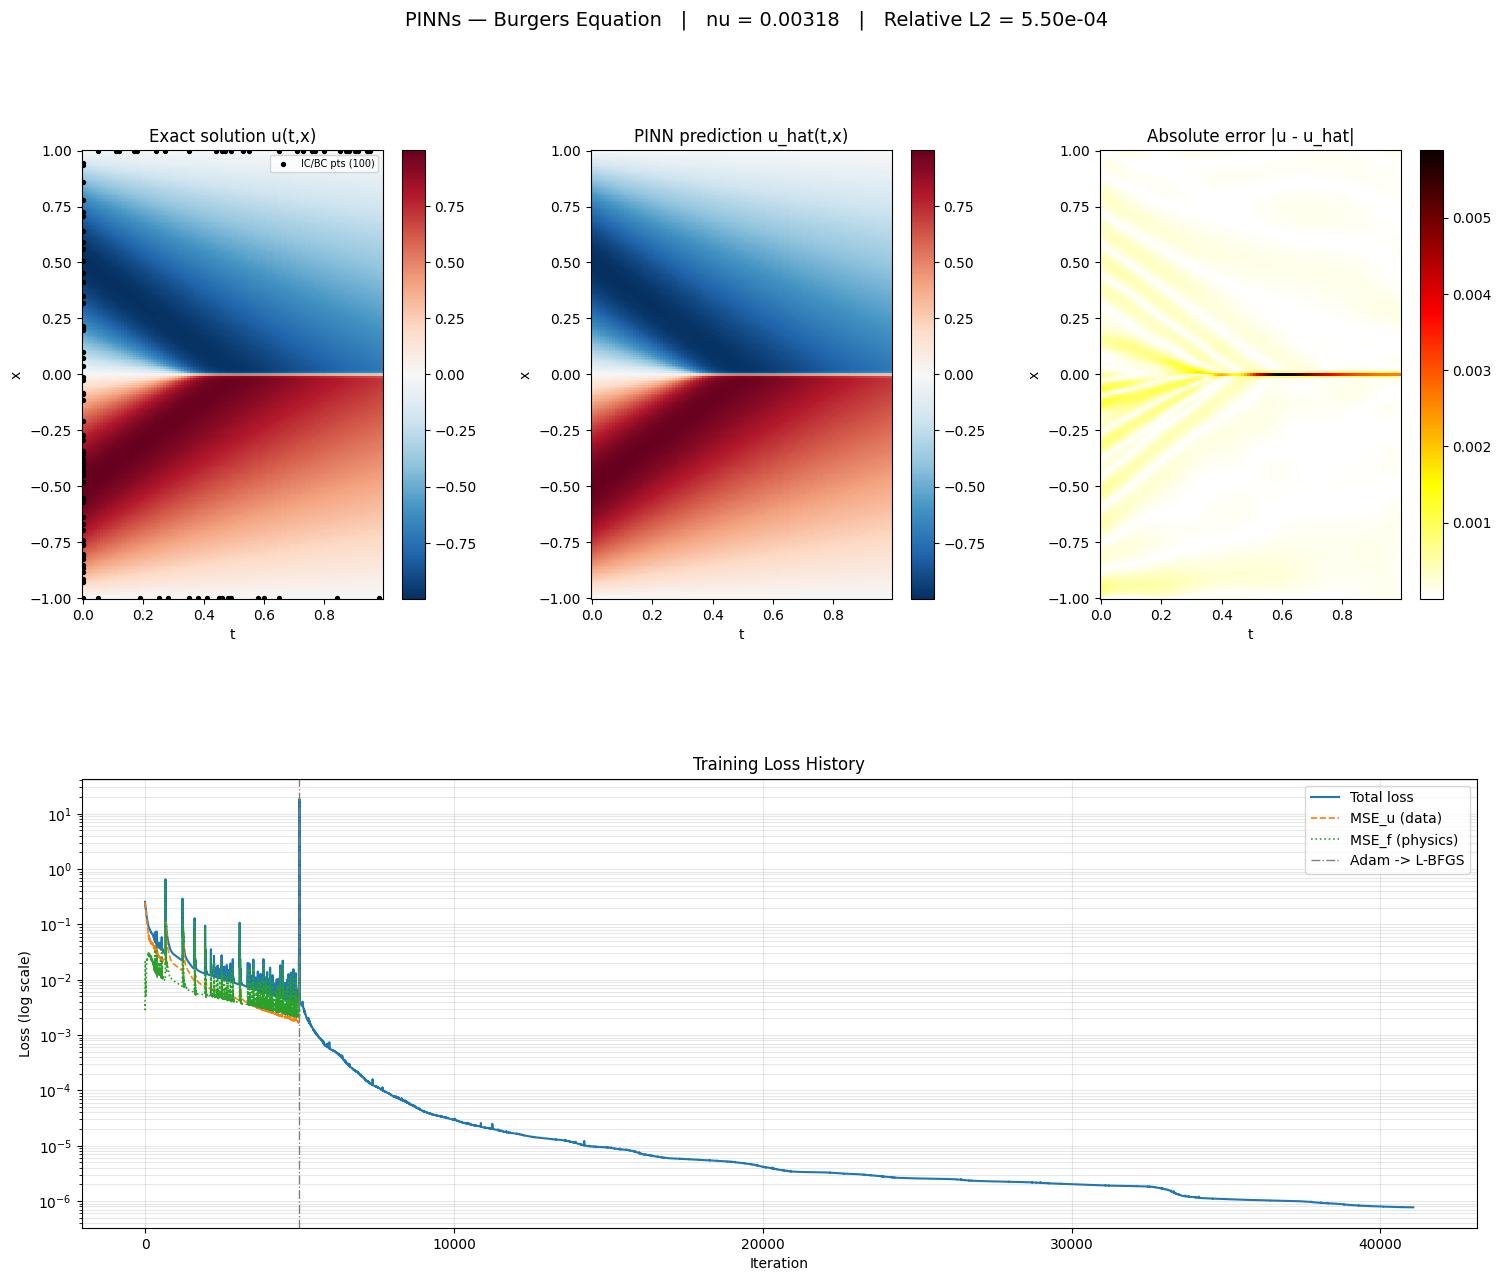

Saved: PINN_Burgers_results.png


In [ ]:
# A : 2-D colour map of exact solution
# B : 2-D colour map of PINN prediction
# C : Point-wise absolute error
# D : Training loss curves (Adam + L-BFGS)

fig = plt.figure(figsize=(18, 14))
fig.suptitle(
    f"PINNs — Burgers Equation   |   nu = {NU:.5f}"
    f"   |   Relative L2 = {l2_error:.2e}",
    fontsize=14, y=0.98,
)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# Panel A – exact
ax0 = fig.add_subplot(gs[0, 0])
c0  = ax0.pcolormesh(T_mesh, X_mesh, u_star, cmap="RdBu_r", shading="auto")
fig.colorbar(c0, ax=ax0)
ax0.set_title("Exact solution u(t,x)")
ax0.set_xlabel("t"); ax0.set_ylabel("x")
ax0.scatter(t_train_u, x_train_u, s=8, c="k", zorder=3,
            label=f"IC/BC pts ({N_u})")
ax0.legend(fontsize=7)

# Panel B – PINN
ax1 = fig.add_subplot(gs[0, 1])
c1  = ax1.pcolormesh(T_mesh, X_mesh, u_pred, cmap="RdBu_r", shading="auto",
                     vmin=u_star.min(), vmax=u_star.max())
fig.colorbar(c1, ax=ax1)
ax1.set_title("PINN prediction u_hat(t,x)")
ax1.set_xlabel("t"); ax1.set_ylabel("x")

# Panel C – error
ax2 = fig.add_subplot(gs[0, 2])
err = np.abs(u_star - u_pred)
c2  = ax2.pcolormesh(T_mesh, X_mesh, err, cmap="hot_r", shading="auto")
fig.colorbar(c2, ax=ax2)
ax2.set_title("Absolute error |u - u_hat|")
ax2.set_xlabel("t"); ax2.set_ylabel("x")

# Panel D – loss history
ax3 = fig.add_subplot(gs[1, :])
ax3.semilogy(loss_history["total"], label="Total loss",       lw=1.5)
ax3.semilogy(loss_history["mse_u"], label="MSE_u (data)",    lw=1.2, ls="--")
ax3.semilogy(loss_history["mse_f"], label="MSE_f (physics)", lw=1.2, ls=":")
ax3.axvline(ADAM_EPOCHS, color="gray", ls="-.", lw=1, label="Adam -> L-BFGS")
ax3.set_xlabel("Iteration"); ax3.set_ylabel("Loss (log scale)")
ax3.set_title("Training Loss History")
ax3.legend(); ax3.grid(True, which="both", alpha=0.3)

plt.savefig("PINN_Burgers_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: PINN_Burgers_results.png")

1-D Slices at Three Time Snapshots

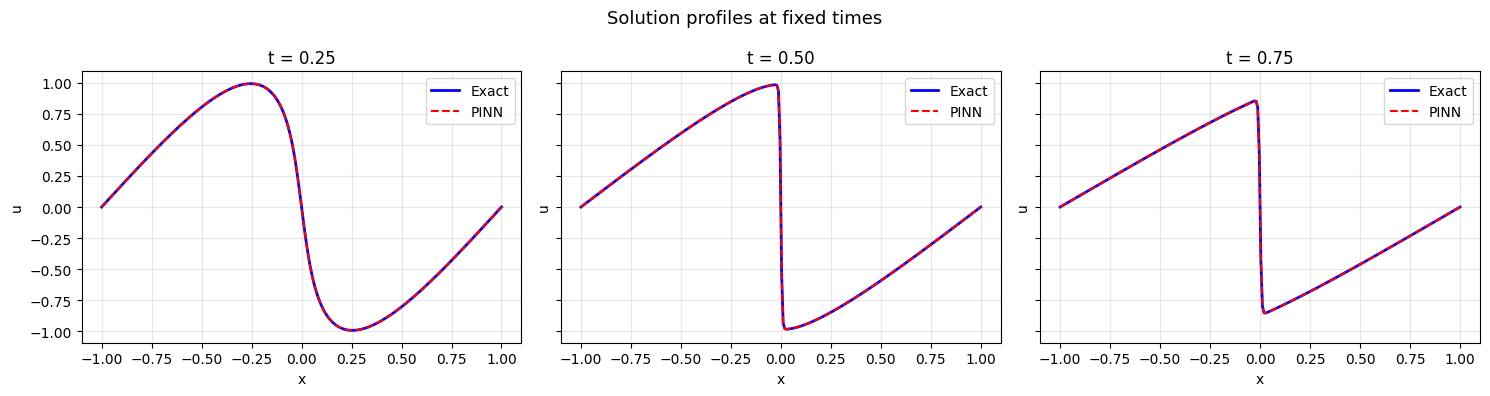

Saved: PINN_Burgers_slices.png


In [ ]:
# Shows the shock wave forming and sharpening over time.

snapshots = [0.25, 0.50, 0.75]
fig2, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig2.suptitle("Solution profiles at fixed times", fontsize=13)

for ax, t_val in zip(axes, snapshots):
    idx_t = np.argmin(np.abs(t_star - t_val))
    ax.plot(x_star, u_star[:, idx_t], "b-",  lw=2,   label="Exact")
    ax.plot(x_star, u_pred[:, idx_t], "r--", lw=1.5, label="PINN")
    ax.set_title(f"t = {t_star[idx_t]:.2f}")
    ax.set_xlabel("x"); ax.set_ylabel("u")
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("PINN_Burgers_slices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: PINN_Burgers_slices.png")

Ablation Study – PINN vs Pure Data Network (physics loss OFF)


Ablation: training WITHOUT physics loss ...

Relative L2 — PINN (physics ON)  : 5.5041e-04
Relative L2 — Data only           : 8.2039e-01
Error reduction factor            : 1490.5x


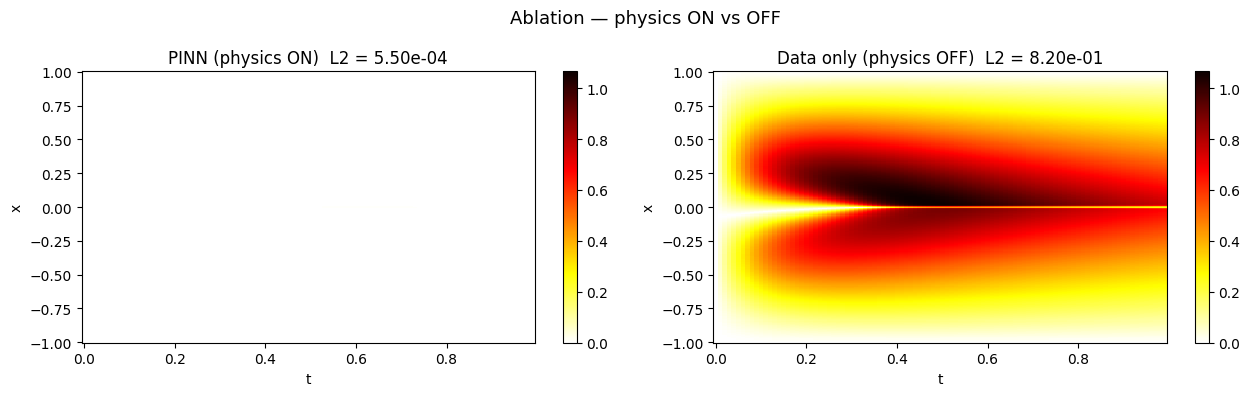

Saved: PINN_Burgers_ablation.png


In [ ]:
print("\n" + "=" * 55)
print("Ablation: training WITHOUT physics loss ...")
print("=" * 55)

model_nd = BurgersPINN(LAYER_SIZES, NU)
adam_nd  = tf.keras.optimizers.Adam(learning_rate=1e-3)

for epoch in range(1, ADAM_EPOCHS + 1):
    with tf.GradientTape() as tape:
        u_pred_nd = model_nd(t_u, x_u)
        loss_nd   = tf.reduce_mean(tf.square(u_u - u_pred_nd))
    grads = tape.gradient(loss_nd, model_nd.trainable_variables)
    adam_nd.apply_gradients(zip(grads, model_nd.trainable_variables))

u_nd = model_nd(t_pred_tf, x_pred_tf).numpy().reshape(T_mesh.shape)

l2_nd = np.linalg.norm(u_star - u_nd) / np.linalg.norm(u_star)

print(f"\nRelative L2 — PINN (physics ON)  : {l2_error:.4e}")
print(f"Relative L2 — Data only           : {l2_nd:.4e}")
print(f"Error reduction factor            : {l2_nd / l2_error:.1f}x")

# Side-by-side error maps
fig3, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
fig3.suptitle("Ablation — physics ON vs OFF", fontsize=13)

vmax = max(np.abs(u_star - u_pred).max(), np.abs(u_star - u_nd).max())

c_a = a1.pcolormesh(T_mesh, X_mesh, np.abs(u_star - u_pred),
                    cmap="hot_r", shading="auto", vmin=0, vmax=vmax)
fig3.colorbar(c_a, ax=a1)
a1.set_title(f"PINN (physics ON)  L2 = {l2_error:.2e}")
a1.set_xlabel("t"); a1.set_ylabel("x")

c_b = a2.pcolormesh(T_mesh, X_mesh, np.abs(u_star - u_nd),
                    cmap="hot_r", shading="auto", vmin=0, vmax=vmax)
fig3.colorbar(c_b, ax=a2)
a2.set_title(f"Data only (physics OFF)  L2 = {l2_nd:.2e}")
a2.set_xlabel("t"); a2.set_ylabel("x")

plt.tight_layout()
plt.savefig("PINN_Burgers_ablation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: PINN_Burgers_ablation.png")

Final Summary

In [ ]:
print("\n" + "=" * 55)
print("FINAL RESULTS SUMMARY")
print("=" * 55)
print(f"  Viscosity nu              : {NU:.6f}")
print(f"  IC/BC points   (N_u)      : {N_u}")
print(f"  Collocation pts (N_f)     : {N_f}")
print(f"  Network architecture      : {LAYER_SIZES}")
print(f"  Adam epochs               : {ADAM_EPOCHS}")
print(f"  L-BFGS iterations         : {len(lbfgs_loss_history)}")
print(f"  PINN  Relative L2 error   : {l2_error:.4e}")
print(f"  Data-only Relative L2     : {l2_nd:.4e}")
print(f"  Error reduction           : {l2_nd / l2_error:.1f}x")
print("=" * 55)


FINAL RESULTS SUMMARY
  Viscosity nu              : 0.003183
  IC/BC points   (N_u)      : 100
  Collocation pts (N_f)     : 10000
  Network architecture      : [2, 20, 20, 20, 20, 20, 20, 20, 20, 1]
  Adam epochs               : 5000
  L-BFGS iterations         : 36063
  PINN  Relative L2 error   : 5.5041e-04
  Data-only Relative L2     : 8.2039e-01
  Error reduction           : 1490.5x
